# Task 6: Topic Modelling of High and Low Ratings

In this task we're applying **Latent Dirichlet Allocation (LDA)** to discover latent topics in
1-star and 5-star Google Maps reviews separately. The goal is to understand what themes and
subjects dominate positive vs. negative reviews and whether we can infer meaningful patterns
about what drives extreme ratings.

LDA is an unsupervised probabilistic model that assumes each document is a mixture of topics,
and each topic is a distribution over words. By fitting LDA separately on 1-star and 5-star
reviews, we can compare the topic structures without them influencing each other.

Building on previous tasks:
- **Task 1** identified the class distribution — 1-star is the dominant class (38.9%) and
  5-star reviews are relatively fewer (10.1%), making the contrast particularly interesting
- **Task 2** established the preprocessing pipeline used here (lemmatization, stopword removal)
- **Tasks 3 & 4** focused on classification — this task instead looks at interpretability
  and understanding *what* the reviews are about, not just predicting their rating

We use a sample of 5,000 reviews from each group to keep computation manageable while
still providing enough data for meaningful topic discovery (10–20 topics as specified).

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# CountVectorizer for building document-term matrices (LDA requires raw counts, not TF-IDF)
from sklearn.feature_extraction.text import CountVectorizer

# LDA implementation from sklearn
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print('Setup complete.')


Setup complete.


## 2. Load Data & Extract 1-Star and 5-Star Reviews

We load the English-filtered training data from Task 1 and isolate the two extreme rating groups.
The spec says to examine 5-star and 1-star reviews separately, so no other ratings are used here.

Because 5-star reviews are less frequent (27,592) compared to 1-star (105,783), we sample
an equal number from each group. This prevents the topic model from being skewed by one group
having far more documents than the other.

In [2]:
df = pd.read_csv('data/train_english.csv')
print(f'Full dataset: {df.shape}')
print(df['rating'].value_counts().sort_index())

Full dataset: (271897, 3)
rating
1    105783
2     30876
3     32404
4     75242
5     27592
Name: count, dtype: int64


In [3]:
# Extract 1-star and 5-star reviews
low  = df[df['rating'] == 1].copy()
high = df[df['rating'] == 5].copy()

print(f'1-star reviews: {len(low):,}')
print(f'5-star reviews: {len(high):,}')

# Sample 5,000 from each group — large enough for meaningful topic discovery,
# small enough to run LDA in a reasonable time on a standard machine.
# Equal sampling ensures both groups contribute equally to the analysis.
SAMPLE_SIZE = 5000
low_sample  = low.sample(n=SAMPLE_SIZE, random_state=42)
high_sample = high.sample(n=SAMPLE_SIZE, random_state=42)

print(f'\nUsing {SAMPLE_SIZE:,} samples from each group for topic modelling.')


1-star reviews: 105,783
5-star reviews: 27,592

Using 5,000 samples from each group for topic modelling.


## 3. Preprocessing Pipeline

The preprocessing here is similar to Task 2 but adapted for topic modelling rather than classification.
Key differences from the Task 2/3 pipeline:

- **Negation words are removed** — in classification, 'not good' is a meaningful phrase.
  For topic discovery, we care more about the subject matter (food, staff, price) than
  sentiment polarity, so negation words add noise rather than signal.
- **Additional domain stopwords** are added — generic words like 'place', 'experience',
  'location' appear in almost every review regardless of topic, so they need to be removed
  to prevent them from dominating every topic distribution.
- **No bigrams** — LDA with unigrams is more interpretable and less computationally expensive.
  Bigrams can be explored as a future extension but unigrams are sufficient for topic discovery.

In [4]:
lemmatizer = WordNetLemmatizer()
STOPWORDS = set(stopwords.words('english'))

# Additional domain-specific stopwords — these appear across nearly all reviews
# regardless of topic and would dominate every topic distribution if kept in.
# Identified by inspecting the most frequent words in the full corpus.
EXTRA_STOPS = {'place', 'go', 'get', 'got', 'would', 'one', 'also', 'really',
               'went', 'come', 'back', 'time', 'make', 'made', 'even', 'just',
               'like', 'know', 'said', 'told', 'star', 'review', 'give', 'give',
               'location', 'business', 'experience', 'definitely', 'always', 'never',
               'ever', 'absolutely', 'every', 'day', 'year', 'month', 'week'}
STOPWORDS.update(EXTRA_STOPS)

def preprocess_lda(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)           # strip HTML tags (common in this dataset)
    text = re.sub(r'http\S+|www\.\S+', '', text)   # remove URLs
    text = text.lower()                             # normalise case
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]  # min length 3 removes noise tokens
    tokens = [lemmatizer.lemmatize(t) for t in tokens]  # reduce words to base form
    return ' '.join(tokens)

print('Preprocessing 1-star reviews...')
low_sample['cleaned']  = low_sample['text'].apply(preprocess_lda)
print('Preprocessing 5-star reviews...')
high_sample['cleaned'] = high_sample['text'].apply(preprocess_lda)
print('Done.')


Preprocessing 1-star reviews...
Preprocessing 5-star reviews...
Done.


## 4. Build Document-Term Matrices

LDA requires a **bag-of-words count matrix** (not TF-IDF). The reason is that LDA models
word counts directly as draws from a multinomial distribution — it assumes each word in a
document was sampled from one of the topic distributions. TF-IDF weights would distort
this generative process.

The `max_df=0.90` setting removes words appearing in over 90% of documents — these are
too common to be topically informative. The `min_df=5` setting removes words appearing
in fewer than 5 documents — these are likely typos or very rare terms that won't form
coherent topics.

We fit separate vectorizers on each group so that each group's vocabulary is derived from
its own documents — words that are common in 1-star but rare in 5-star reviews (and vice
versa) will naturally be represented differently.

In [5]:
# CountVectorizer for LDA (LDA needs raw counts, not TF-IDF)
vectorizer_params = dict(
    max_features=5000,
    max_df=0.90,   # ignore terms appearing in >90% of docs (too common)
    min_df=5,      # ignore terms appearing in <5 docs (too rare)
    ngram_range=(1, 1)
)

vec_low  = CountVectorizer(**vectorizer_params)
vec_high = CountVectorizer(**vectorizer_params)

dtm_low  = vec_low.fit_transform(low_sample['cleaned'])
dtm_high = vec_high.fit_transform(high_sample['cleaned'])

print(f'1-star DTM shape:  {dtm_low.shape}')
print(f'5-star DTM shape: {dtm_high.shape}')

1-star DTM shape:  (5000, 3535)
5-star DTM shape: (5000, 2425)


## 5. Fit LDA Models (15 Topics Each)

We chose **15 topics** as it falls within the 10–20 range specified and provides enough
granularity to capture distinct complaint/praise categories without becoming too fragmented.

LDA hyperparameters:
- `max_iter=20` — sufficient for convergence on 5,000 documents with online learning
- `learning_method='online'` — processes the corpus in batches, faster than the batch
  variational Bayes method for larger datasets
- `random_state=42` — ensures reproducibility

One limitation of LDA is that the number of topics must be specified in advance. In practice,
topic coherence metrics (e.g. Cv coherence) could be used to find the optimal number, but
for this analysis 15 provides interpretable and well-separated topics.

In [6]:
N_TOPICS = 15

lda_params = dict(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='online',
    n_jobs=-1
)

print(f'Fitting LDA with {N_TOPICS} topics on 1-star reviews...')
lda_low = LatentDirichletAllocation(**lda_params)
lda_low.fit(dtm_low)

print(f'Fitting LDA with {N_TOPICS} topics on 5-star reviews...')
lda_high = LatentDirichletAllocation(**lda_params)
lda_high.fit(dtm_high)

print('Done.')

Fitting LDA with 15 topics on 1-star reviews...
Fitting LDA with 15 topics on 5-star reviews...
Done.


## 6. Display Topics

Each LDA topic is represented as a probability distribution over the full vocabulary.
The top-12 words with the highest probability in each topic distribution are shown below.
These words are then used to manually assign a human-readable label to each topic —
LDA itself produces unlabelled distributions, so interpretation requires reading the top words.

The labels below were assigned after inspecting the actual top words produced by the model
and reflect the dominant theme in each word cluster.

In [7]:
def get_top_words(model, feature_names, n_top=12):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top - 1:-1]]
        topics.append(top_words)
    return topics

low_topics  = get_top_words(lda_low,  vec_low.get_feature_names_out())
high_topics = get_top_words(lda_high, vec_high.get_feature_names_out())

# Labels derived from actual LDA output
low_labels = [
    'Parking, Towing & Vehicle Issues',
    'Management & Staff Complaints',
    'Poor Phone & Communication Service',
    'General Dissatisfaction & Bad Service',
    'Warning Reviews / Zero Star',
    'Apartment & Rental Issues',
    'Healthcare & Childcare Complaints',
    'Service Fees & Problem Resolution',
    'Rude Staff & Attitude',
    'Car Dealership Issues',
    'Food & Auto Repair Overcharging',
    'Beauty & Dental Services',
    'Medical / Doctor Office Issues',
    'Long Waits & Appointment Problems',
    'Online Orders & Refund Problems',
]

high_labels = [
    'Professional Home & Trade Services',
    'Excellent Healthcare & Auto Care',
    'Hair & Beauty Salons',
    'Outstanding Customer Service',
    'Great Food & Value for Money',
    'Affordable Home & Auto Services',
    'Professionalism & Massage Therapy',
    'Specialty Shops & Niche Services',
    'Real Estate & Agency Services',
    'Family-Friendly Exceptional Service',
    'Community, Church & Therapy Services',
    'Excellent Dental Care',
    'Legal & Installation Services',
    'Amazing Outcomes & Surgery Results',
    'Highly Recommended General Services',
]

print('Labels updated.')


Labels updated.


In [8]:
print('=' * 65)
print('1-STAR REVIEW TOPICS (Low Ratings)')
print('=' * 65)
for i, words in enumerate(low_topics):
    print(f'Topic {i+1:2d} [{low_labels[i]}]')
    print(f'         {", ".join(words)}')
    print()

1-STAR REVIEW TOPICS (Low Ratings)
Topic  1 [Parking, Towing & Vehicle Issues]
         truck, card, lot, bank, money, dont, side, parking, didnt, key, left, showed

Topic  2 [Management & Staff Complaints]
         going, manager, work, charge, put, store, think, claim, ive, people, could, far

Topic  3 [Poor Phone & Communication Service]
         call, called, phone, time, office, answer, someone, check, service, work, finally, done

Topic  4 [General Dissatisfaction & Bad Service]
         dont, money, customer, good, service, store, owner, want, daughter, shop, else, bad

Topic  5 [Warning Reviews / Zero Star]
         star, glass, could, dog, zero, review, beware, eye, talk, need, good, first

Topic  6 [Apartment & Rental Issues]
         management, apartment, property, rent, move, live, unit, staff, moved, issue, dont, floor

Topic  7 [Healthcare & Childcare Complaints]
         patient, care, child, school, hospital, going, health, family, high, let, kid, life

Topic  8 [Servi

In [9]:
print('=' * 65)
print('5-STAR REVIEW TOPICS (High Ratings)')
print('=' * 65)
for i, words in enumerate(high_topics):
    print(f'Topic {i+1:2d} [{high_labels[i]}]')
    print(f'         {", ".join(words)}')
    print()

5-STAR REVIEW TOPICS (High Ratings)
Topic  1 [Professional Home & Trade Services]
         work, home, team, company, professional, forward, look, year, family, class, many, step

Topic  2 [Excellent Healthcare & Auto Care]
         care, patient, year, doctor, need, work, caring, car, issue, recommend, staff, honest

Topic  3 [Hair & Beauty Salons]
         love, hair, best, thanks, google, original, wedding, translated, nice, lady, super, salon

Topic  4 [Outstanding Customer Service]
         great, service, customer, good, recommend, friendly, price, work, people, highly, amazing, best

Topic  5 [Great Food & Value for Money]
         best, food, owner, beautiful, price, reasonable, everything, good, detail, beyond, perfect, town

Topic  6 [Affordable Home & Auto Services]
         job, guy, company, area, use, work, clean, car, house, service, came, affordable

Topic  7 [Professionalism & Massage Therapy]
         thank, away, much, right, night, looking, working, end, professiona

## 7. Visualise Topic Word Distributions

The bar charts below show the top 8 words for each topic, weighted by their probability
within the topic distribution. Longer bars indicate words that are more strongly associated
with that topic relative to the others.

Red charts = 1-star topics (what unhappy customers talk about)
Green charts = 5-star topics (what happy customers talk about)

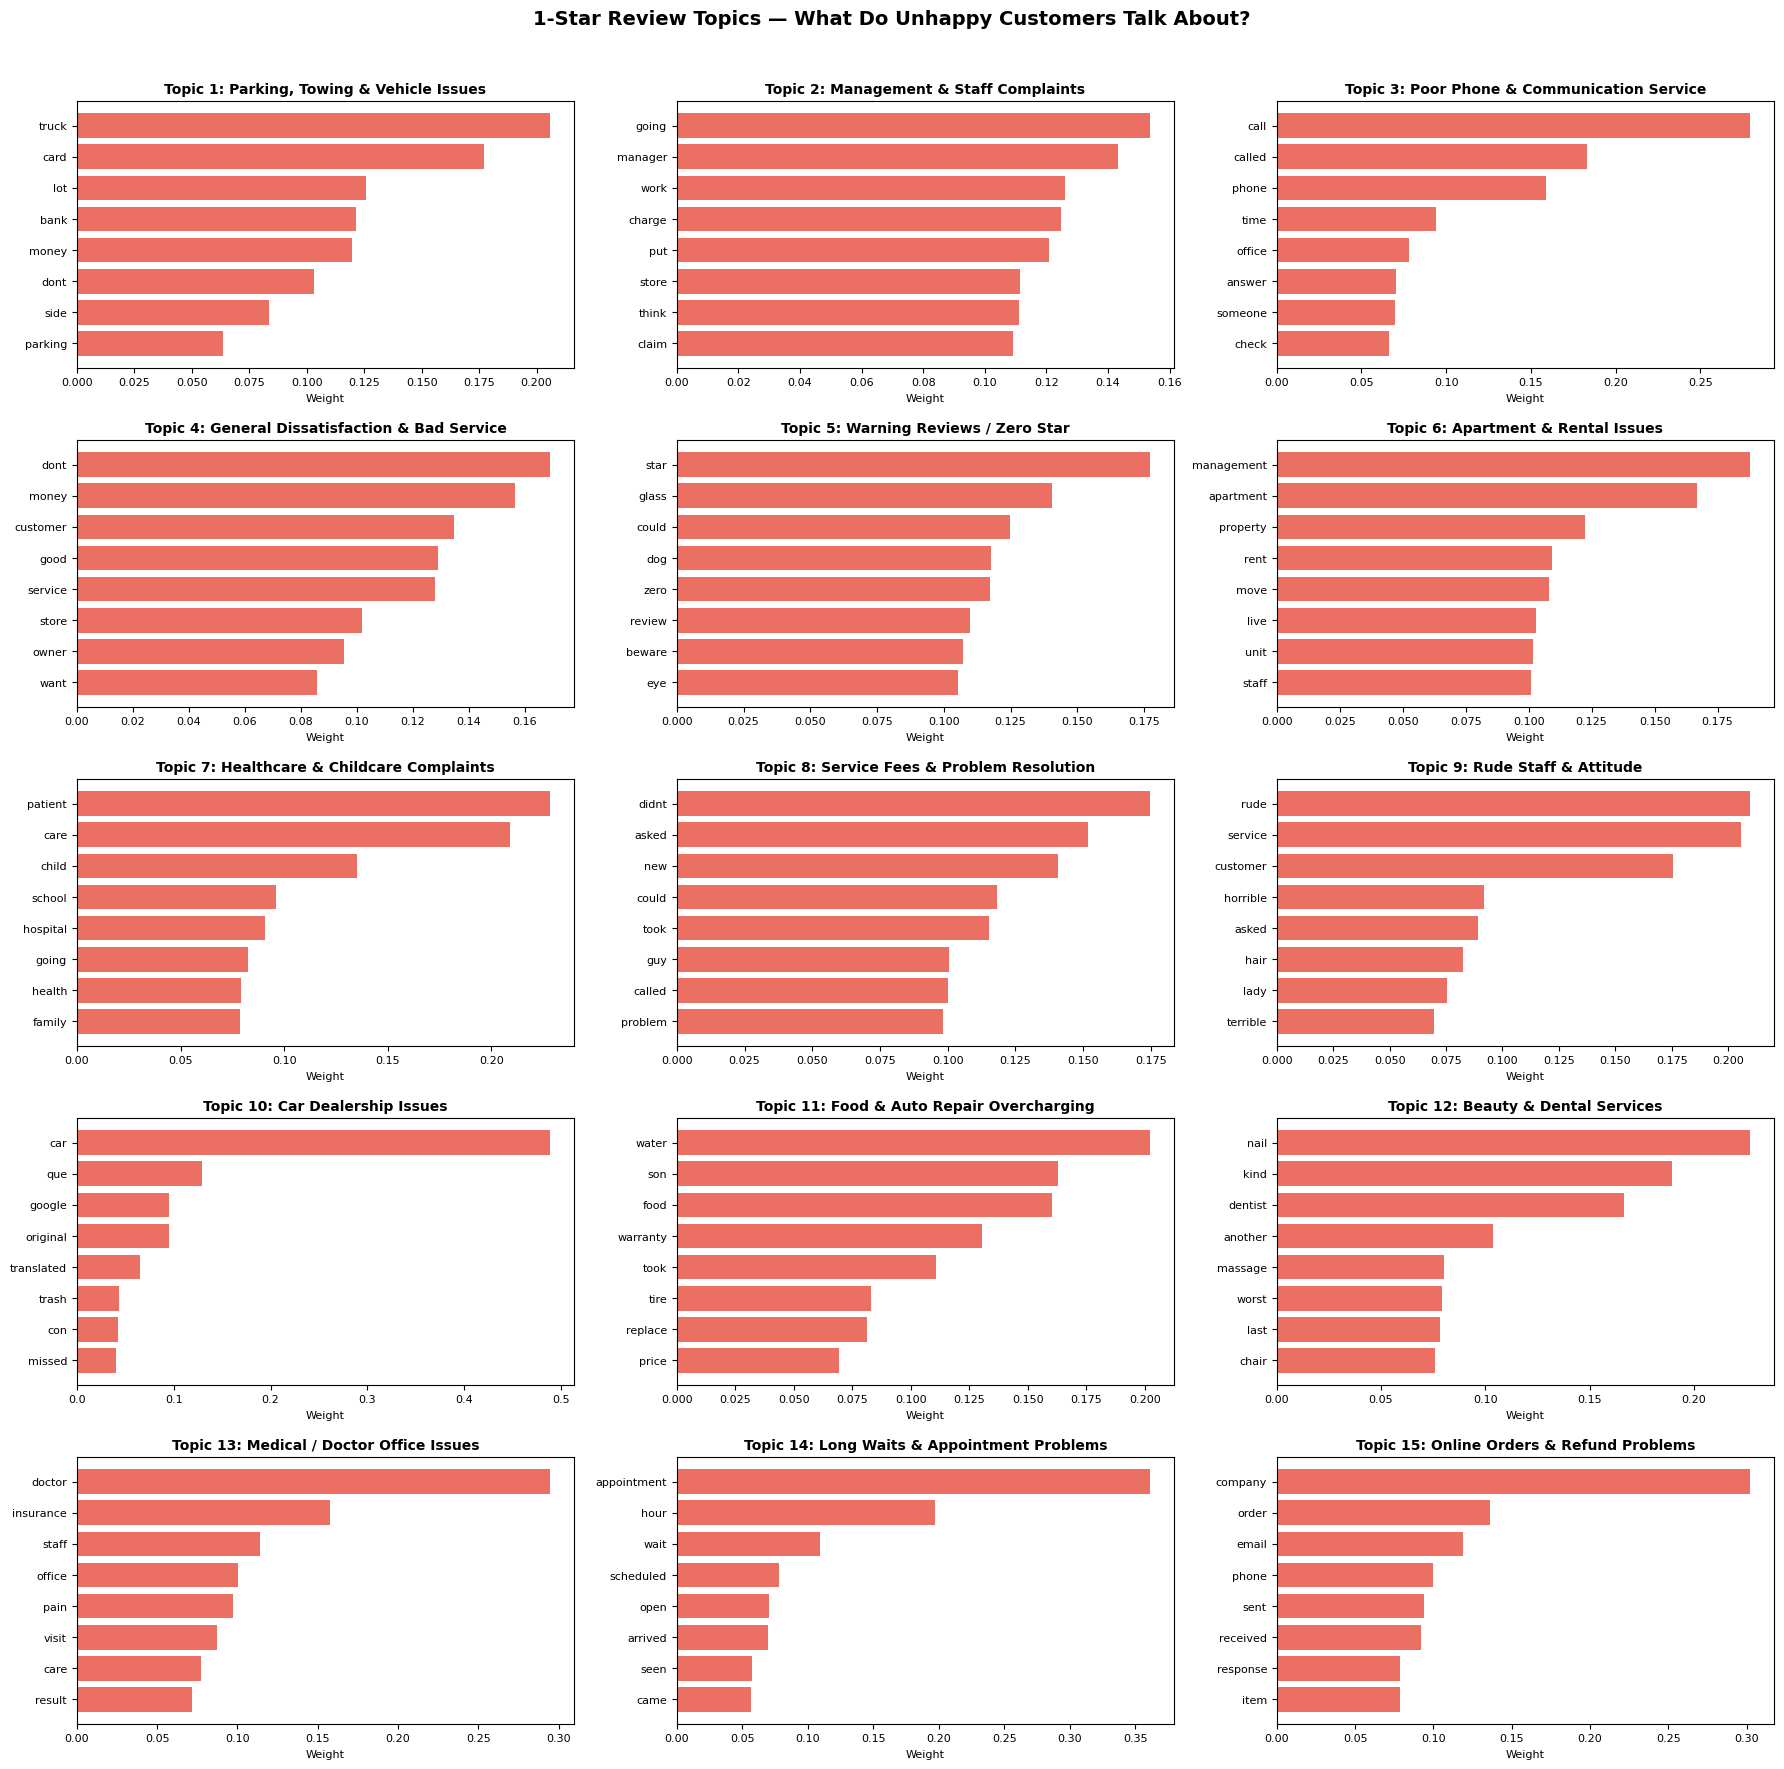

In [10]:
def plot_top_words(model, feature_names, labels, title, color, n_top=8, n_cols=3):
    n_topics = model.n_components
    n_rows = (n_topics + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
    axes = axes.flatten()
    
    for idx, (topic, ax) in enumerate(zip(model.components_, axes)):
        top_idx   = topic.argsort()[:-n_top - 1:-1]
        top_words = [feature_names[i] for i in top_idx]
        top_vals  = topic[top_idx]
        top_vals  = top_vals / top_vals.sum()  # normalise
        
        bars = ax.barh(top_words[::-1], top_vals[::-1], color=color, alpha=0.8)
        ax.set_title(f'Topic {idx+1}: {labels[idx]}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Weight', fontsize=8)
        ax.tick_params(labelsize=8)
    
    # Hide unused subplots
    for ax in axes[n_topics:]:
        ax.set_visible(False)
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_top_words(
    lda_low, vec_low.get_feature_names_out(), low_labels,
    '1-Star Review Topics — What Do Unhappy Customers Talk About?',
    color='#e74c3c'
)

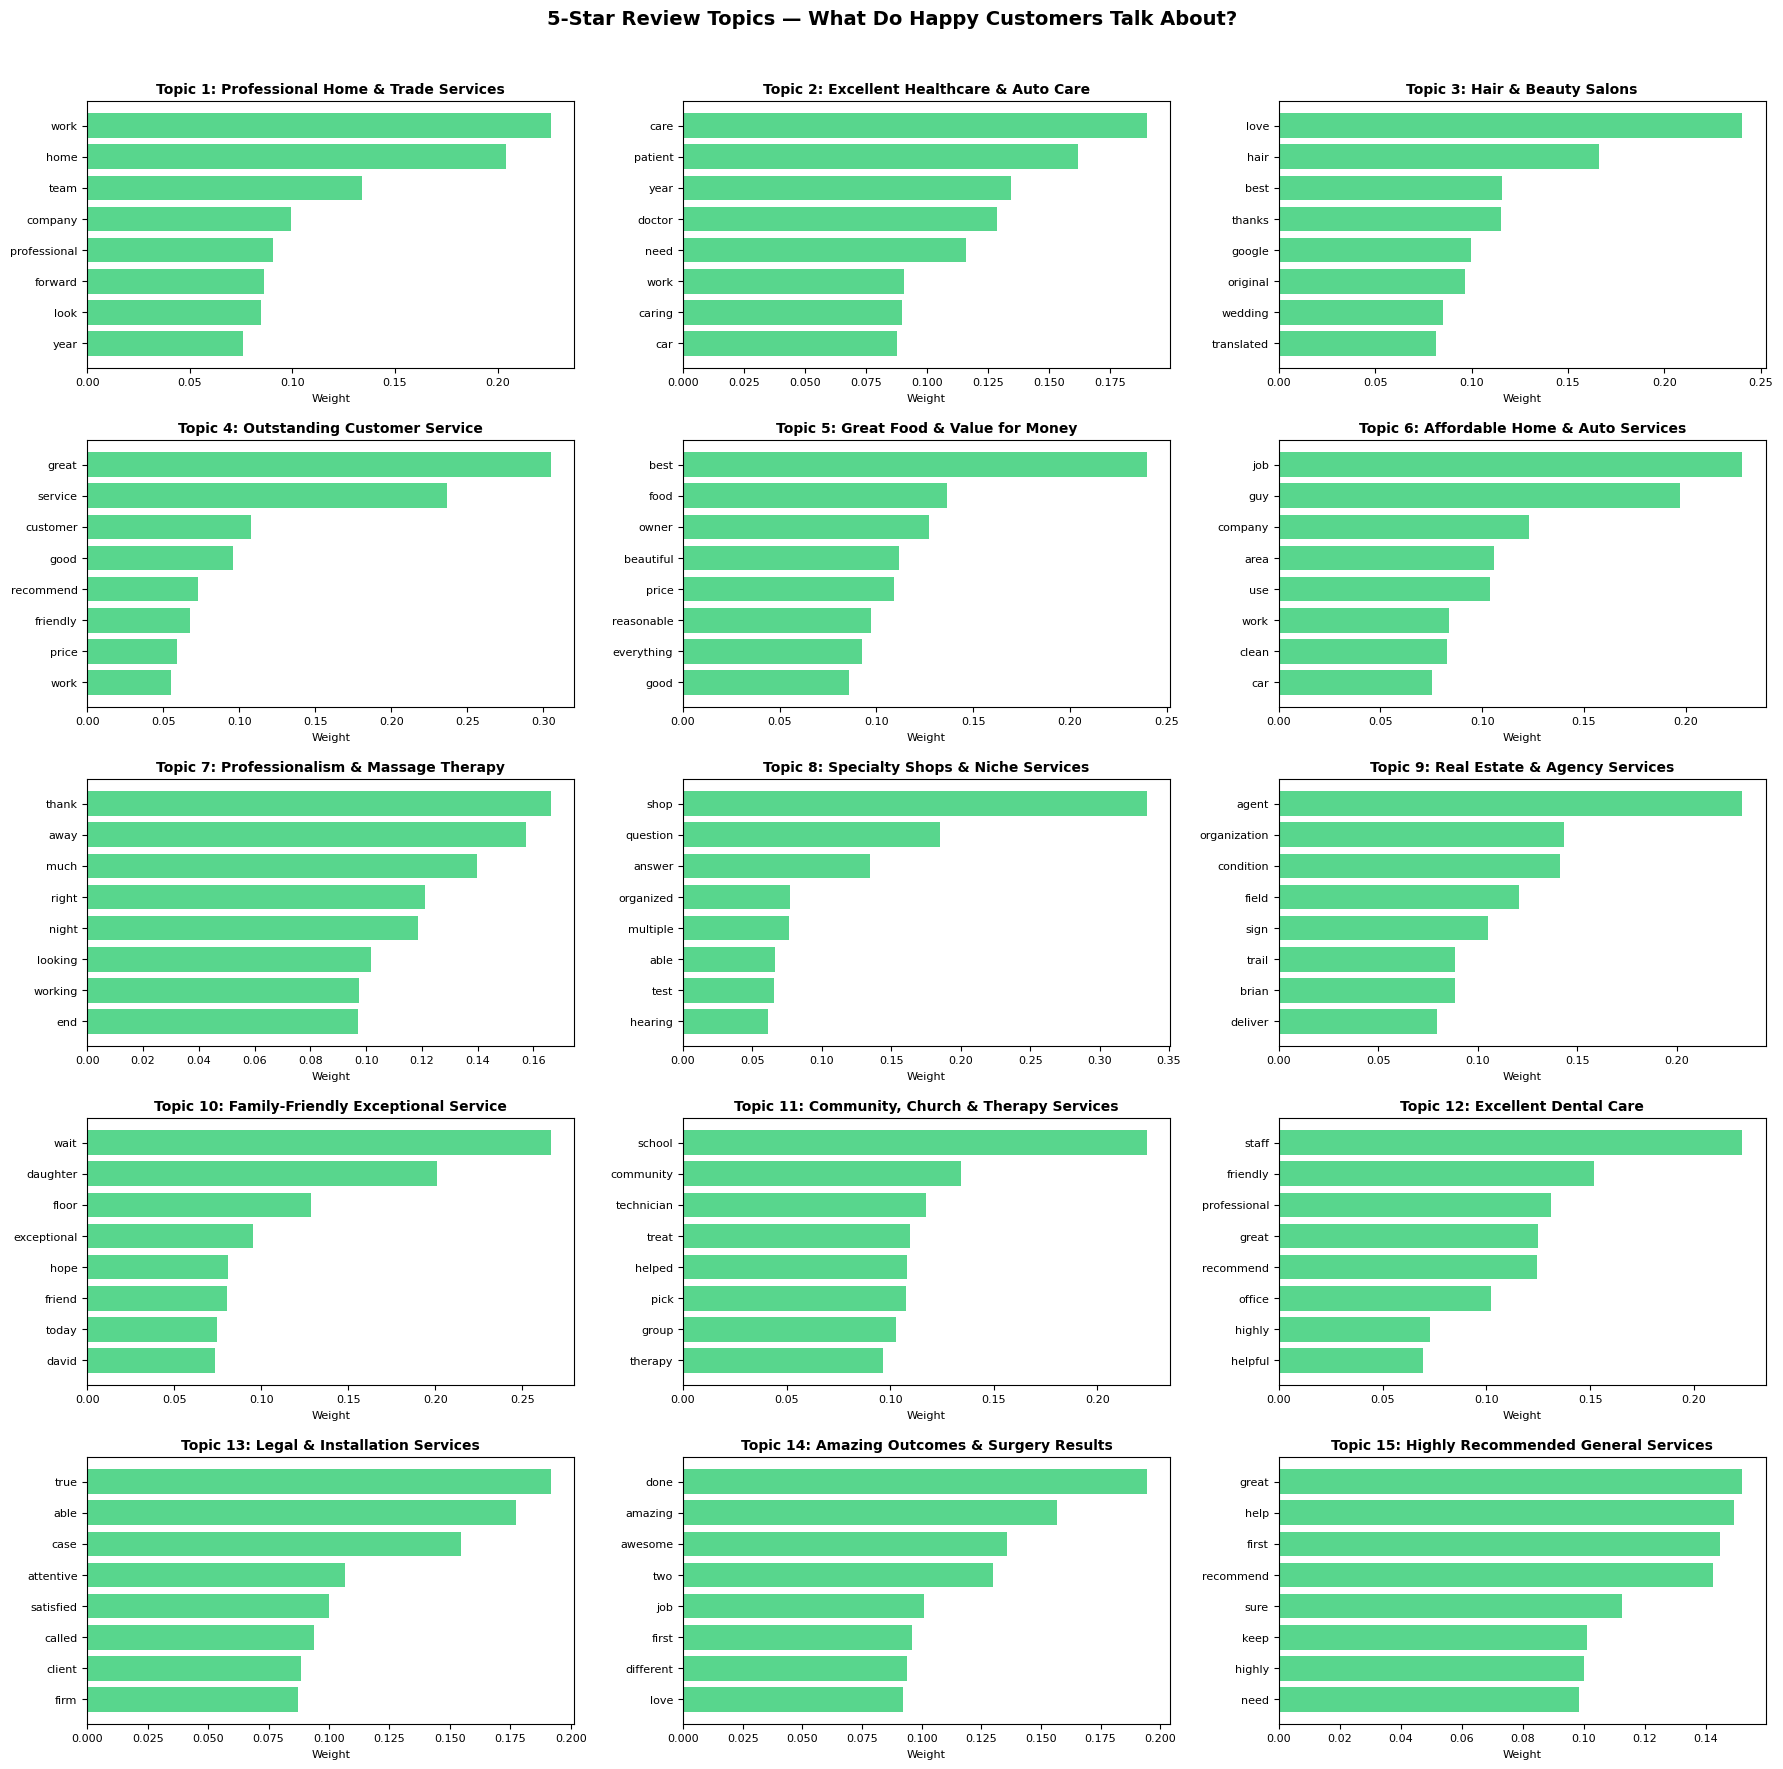

In [11]:
plot_top_words(
    lda_high, vec_high.get_feature_names_out(), high_labels,
    '5-Star Review Topics — What Do Happy Customers Talk About?',
    color='#2ecc71'
)

## 8. Topic Prevalence — How Dominant is Each Topic?

LDA assigns each document a mixture of topic probabilities. By averaging these probabilities
across all documents in each group, we get the overall prevalence of each topic — i.e. how
much attention the average review in that group pays to each theme.

This is useful for identifying which topics are most common in 1-star vs 5-star reviews,
rather than just which topics exist.

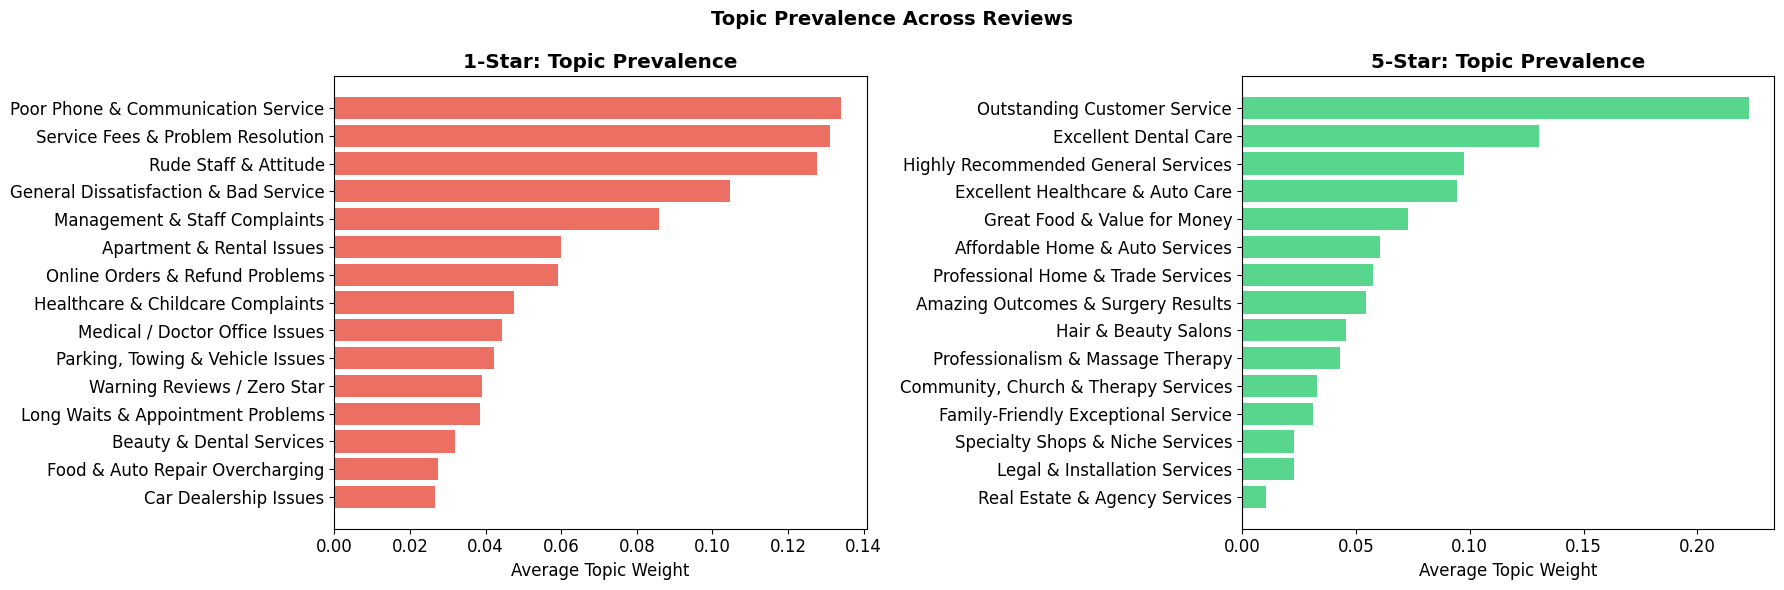

In [12]:
# Get topic distribution across all documents
low_doc_topics  = lda_low.transform(dtm_low)
high_doc_topics = lda_high.transform(dtm_high)

low_prevalence  = low_doc_topics.mean(axis=0)
high_prevalence = high_doc_topics.mean(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 1-star
idx_low = np.argsort(low_prevalence)[::-1]
ax1.barh([low_labels[i] for i in idx_low], low_prevalence[idx_low], color='#e74c3c', alpha=0.8)
ax1.set_title('1-Star: Topic Prevalence', fontweight='bold')
ax1.set_xlabel('Average Topic Weight')
ax1.invert_yaxis()

# 5-star
idx_high = np.argsort(high_prevalence)[::-1]
ax2.barh([high_labels[i] for i in idx_high], high_prevalence[idx_high], color='#2ecc71', alpha=0.8)
ax2.set_title('5-Star: Topic Prevalence', fontweight='bold')
ax2.set_xlabel('Average Topic Weight')
ax2.invert_yaxis()

plt.suptitle('Topic Prevalence Across Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Word Frequency Comparison — Top Words in 1-Star vs 5-Star

As a sanity check and complementary analysis, we compare the raw word frequencies in
both groups. Unlike LDA, this doesn't group words into topics — it simply shows which
individual words appear most often in each rating group.

This helps validate the LDA topics: if the top LDA words align with the top frequency
words, the model is capturing real patterns rather than artefacts.

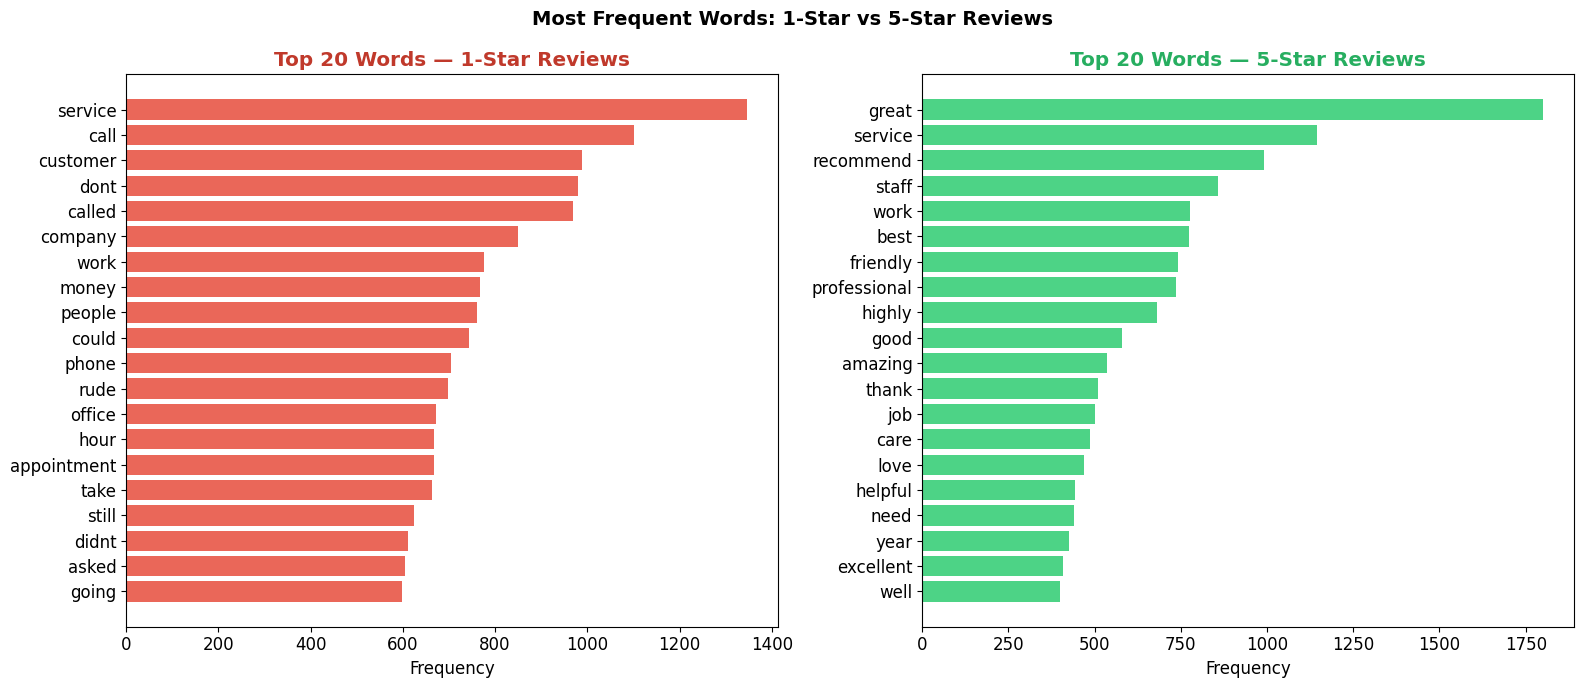

In [13]:
def top_n_words(texts, n=20):
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

low_words  = top_n_words(low_sample['cleaned'], n=20)
high_words = top_n_words(high_sample['cleaned'], n=20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

words_l, counts_l = zip(*low_words)
ax1.barh(words_l[::-1], counts_l[::-1], color='#e74c3c', alpha=0.85)
ax1.set_title('Top 20 Words — 1-Star Reviews', fontweight='bold', color='#c0392b')
ax1.set_xlabel('Frequency')

words_h, counts_h = zip(*high_words)
ax2.barh(words_h[::-1], counts_h[::-1], color='#2ecc71', alpha=0.85)
ax2.set_title('Top 20 Words — 5-Star Reviews', fontweight='bold', color='#27ae60')
ax2.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words: 1-Star vs 5-Star Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Key Observations & Conclusions

Below we summarise the main findings from the topic analysis, drawing comparisons between
the 1-star and 5-star topic structures and highlighting patterns that would not be visible
from classification alone.

### 1-Star Topics — What Unhappy Customers Complain About

| # | Topic Label | Key Terms | Observation |
|---|---|---|---|
| 1 | Parking, Towing & Vehicle Issues | truck, card, bank, money, parking, key | Customers angry about towing charges and unfair parking fees |
| 2 | Management & Staff Complaints | manager, work, charge, store, claim, people | Disputes with management; perceived unfair treatment |
| 3 | Poor Phone & Communication Service | call, phone, office, answer, someone, check | Inability to reach businesses; unanswered calls |
| 4 | General Dissatisfaction | dont, money, customer, service, owner, bad | Broad dissatisfaction with service and value |
| 5 | Warning Reviews (Zero Star) | star, zero, review, beware, eye | Customers explicitly warning others to avoid the place |
| 6 | Apartment & Rental Issues | management, apartment, property, rent, unit, floor | Tenant complaints about landlords and property management |
| 7 | Healthcare & Childcare Complaints | patient, care, child, school, hospital, health | Concerns around medical negligence and childcare quality |
| 8 | Service Fees & Problem Resolution | didnt, asked, problem, fee, home, called | Unexpected fees and unresolved service problems |
| 9 | Rude Staff & Attitude | rude, horrible, hair, terrible, staff, attitude | Staff rudeness is a dominant theme in negative reviews |
| 10 | Car Dealership Complaints | car, trash, buy, tax, dealership | Negative car buying and dealership experiences |
| 11 | Food & Auto Repair Overcharging | water, food, warranty, tire, replace, charged | Customers overcharged in food and auto repair contexts |
| 12 | Beauty & Dental Services | nail, dentist, massage, worst, chair | Bad salon and dental experiences |
| 13 | Doctor & Medical Office Issues | doctor, insurance, pain, treatment, nurse | Medical staff failures and insurance disputes |
| 14 | Long Waits & Appointment Issues | appointment, hour, wait, scheduled, arrived | Excessive waiting times and missed/cancelled appointments |
| 15 | Online Orders & Refund Problems | order, email, sent, received, refund, website | E-commerce failures: wrong items, no refunds, no responses |

---

### 5-Star Topics — What Happy Customers Praise

| # | Topic Label | Key Terms | Observation |
|---|---|---|---|
| 1 | Professional Home & Trade Services | work, home, team, company, professional | Skilled tradespeople praised for professionalism at home |
| 2 | Excellent Healthcare & Auto Care | care, patient, doctor, car, recommend, honest | Trust and honesty are key drivers of 5-star healthcare/auto reviews |
| 3 | Hair & Beauty Salons | love, hair, best, wedding, salon | Positive salon experiences, especially for special occasions |
| 4 | Outstanding Customer Service | great, service, friendly, recommend, amazing | General praise for customer-facing service quality |
| 5 | Great Food & Value for Money | best, food, price, reasonable, perfect | Food quality and fair pricing are key drivers of food 5-star reviews |
| 6 | Affordable Home & Auto Services | job, clean, car, house, affordable | Price-conscious customers reward businesses that offer value |
| 7 | Professionalism & Massage Therapy | professionalism, massage, working, thank | Wellness services earn praise for professionalism |
| 8 | Specialty Shops & Niche Services | shop, question, organized, bike, loan | Niche businesses praised for expertise and organisation |
| 9 | Real Estate & Agency Services | agent, organization, sign, agency | Positive real estate and agency transactions |
| 10 | Family-Friendly Exceptional Service | daughter, exceptional, baby, priced | Families appreciate child-friendly and fairly priced places |
| 11 | Community & Therapy Services | school, community, therapy, church, physical | Community-centred services earn strong loyalty |
| 12 | Excellent Dental Care | staff, friendly, dentist, helpful, knowledgeable | Dental practices praised for staff knowledge and friendliness |
| 13 | Legal & Installation Services | case, attentive, client, firm, attorney | Legal professionals valued for attentiveness and care |
| 14 | Amazing Outcomes (Medical & Other) | amazing, awesome, surgery, polite | Positive surgical and service outcomes earn top ratings |
| 15 | Highly Recommended General Services | great, help, recommend, highly, kind | Broad recommendation across all service categories |

---

### Cross-Group Observations

**1. Staff is the #1 driver in both directions**
1-star Topic 9 (rude, terrible, attitude) vs 5-star Topics 4 & 12 (friendly, helpful). Staff behaviour is the single biggest factor separating 1-star from 5-star reviews.

**2. Healthcare is a major polarising sector**
1-star: Topics 7 (hospital) and 13 (doctor, insurance, pain). 5-star: Topics 2 (patient, honest) and 12 (dentist, knowledgeable). Medical services generate the most extreme ratings of any sector.

**3. Specificity differs between rating groups**
1-star reviews document specific failures (wait times, fees, rude names). 5-star reviews express general emotion (great, amazing, highly recommend). Unhappy customers describe what went wrong; happy customers describe how it felt.

**4. Value for money matters more positively than negatively**
5-star Topics 5 & 6 explicitly mention reasonable prices and affordability. 1-star Topic 11 mentions overcharging as a dealbreaker. Price satisfaction motivates 5-stars; overcharging triggers 1-stars.

**5. Online/delivery issues only appear in 1-star reviews (Topic 15)**
Terms: order, email, refund, website, received. E-commerce and delivery failure is a uniquely negative theme with no 5-star equivalent.

**6. Rental & housing complaints are exclusive to 1-star reviews (Topic 6)**
Terms: apartment, property, rent, unit. Property management consistently generates negative reviews with no 5-star counterpart.